# Sensitivity analysis simplified vs full range

                Full Mean  Simplified Mean  Difference
min              5.338777         6.232108    0.893331
lower_quantile   6.205692         6.248463    0.042771
median           7.477847         7.475425   -0.002422
upper_quantile   9.371473         9.279918   -0.091554
max             12.225359         9.304272   -2.921087


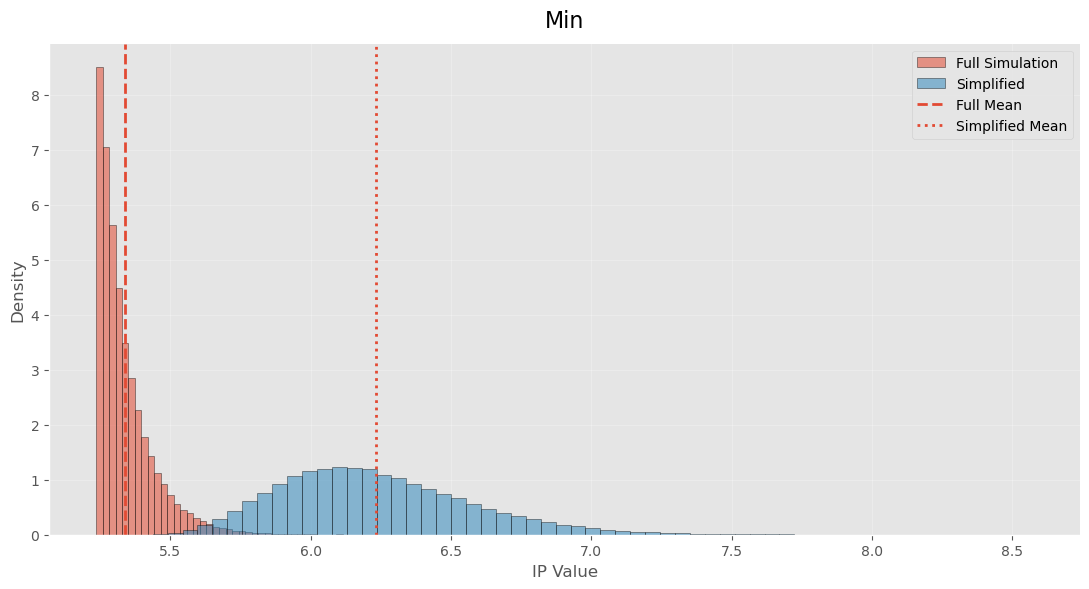

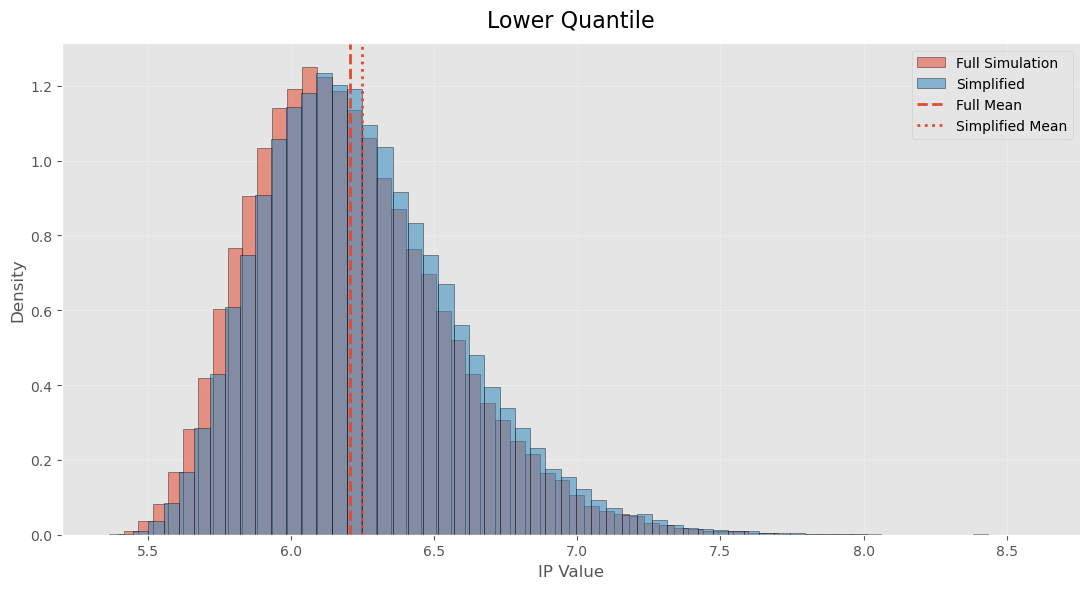

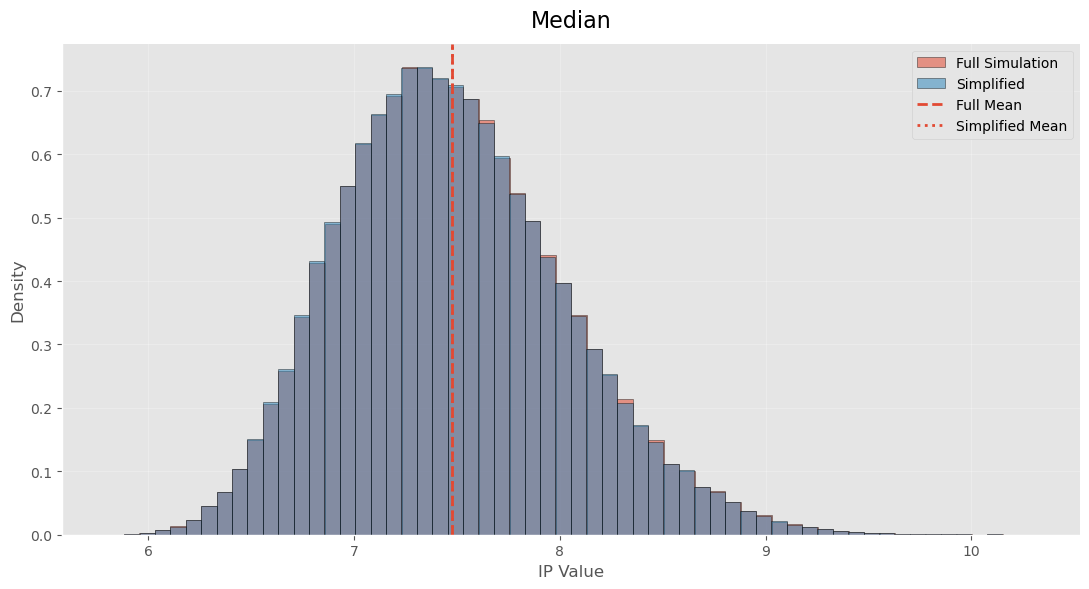

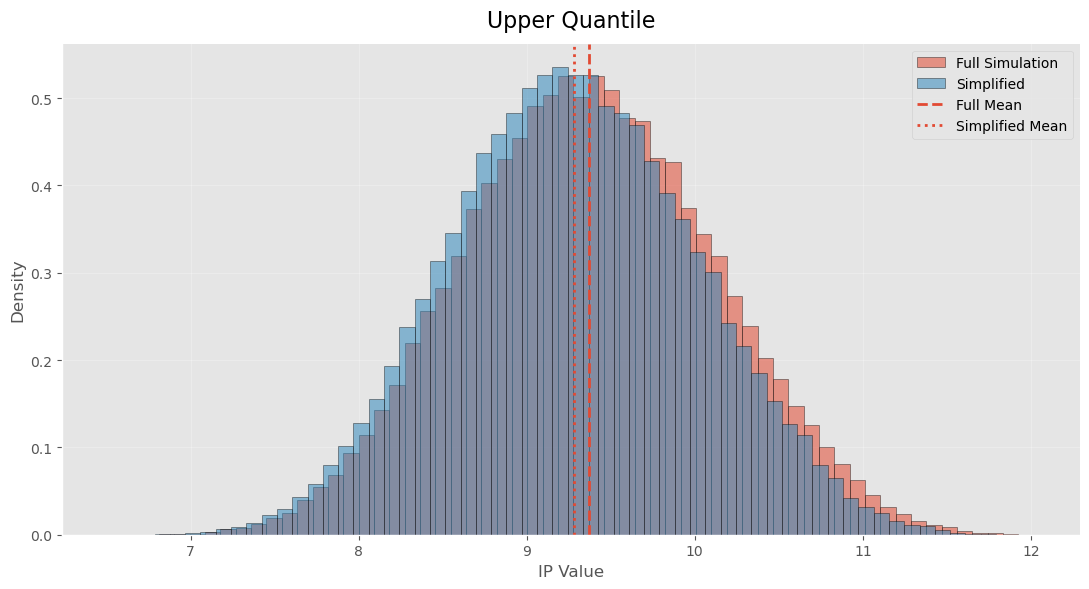

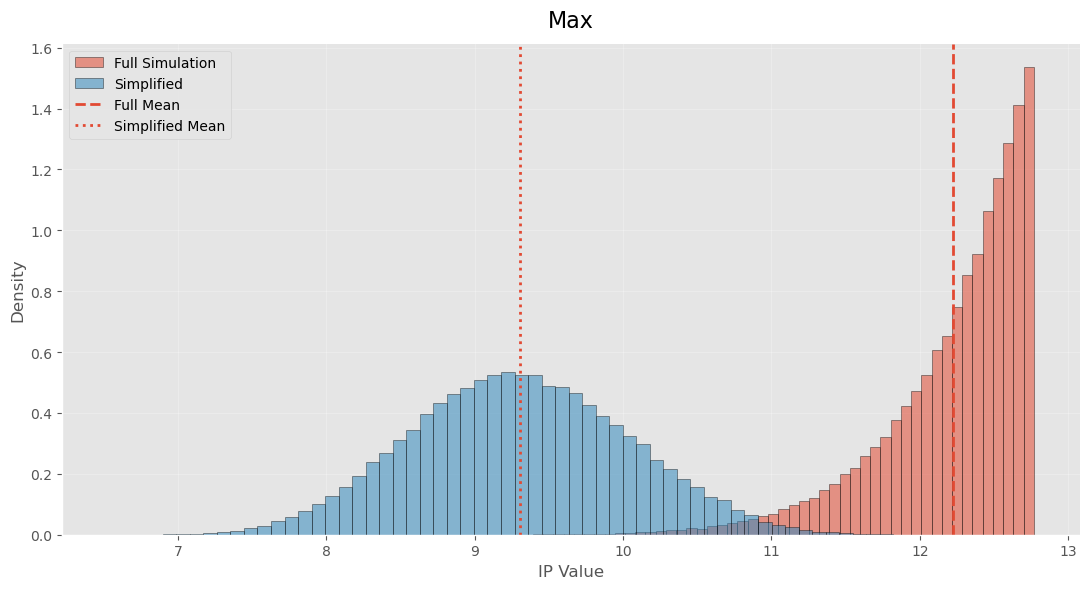

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

def ip_value(
    growth_rate,
    interest_rate,
    routine_return_rate,
    rnd_pct,
    initial_income=1,
    years=100
):
    t = np.arange(1, years + 1)
    income = initial_income * (1 + growth_rate) ** (t - 1)
    rnd_cost = rnd_pct * income
    cash_flow = income - rnd_cost - routine_return_rate * rnd_cost
    pv = np.sum(cash_flow / (1 + interest_rate) ** t)
    return pv

def summary_stats(x):
    return {
        "min": np.min(x),
        "lower_quantile": np.quantile(x, 0.25),
        "median": np.median(x),
        "upper_quantile": np.quantile(x, 0.75),
        "max": np.max(x)
    }

def run_full_simulation(
    n_draws=30,
    rr_low=0.05,
    rr_high=0.10,
    ir_low=0.10,
    ir_high=0.20,
    growth_rate=0.03,
    rnd_pct=0.10,
    initial_income=1,
    years=100
):
    rr = np.random.uniform(rr_low, rr_high, n_draws)
    ir = np.random.uniform(ir_low, ir_high, n_draws)

    vals = []

    for r in rr:
        for i in ir:
            vals.append(
                ip_value(
                    growth_rate,
                    i,
                    r,
                    rnd_pct,
                    initial_income,
                    years
                )
            )

    vals = np.array(vals)
    return summary_stats(vals), rr, ir

def run_simplified_simulation(
    rr,
    ir,
    growth_rate=0.03,
    rnd_pct=0.10,
    initial_income=1,
    years=100
):
    rr_pts = np.quantile(rr, [0.25, 0.50, 0.75])
    ir_pts = np.quantile(ir, [0.25, 0.50, 0.75])

    vals = []

    for r in rr_pts:
        for i in ir_pts:
            vals.append(
                ip_value(
                    growth_rate,
                    i,
                    r,
                    rnd_pct,
                    initial_income,
                    years
                )
            )

    vals = np.array(vals)
    return summary_stats(vals)

def monte_carlo(
    reps=100000,
    n_draws=30,
    rr_low=0.05,
    rr_high=0.10,
    ir_low=0.10,
    ir_high=0.20,
    growth_rate=0.03,
    rnd_pct=0.10,
    initial_income=1,
    years=100
):
    full_results = []
    simple_results = []

    for _ in range(reps):
        full_stat, rr, ir = run_full_simulation(
            n_draws,
            rr_low,
            rr_high,
            ir_low,
            ir_high,
            growth_rate,
            rnd_pct,
            initial_income,
            years
        )

        simple_stat = run_simplified_simulation(
            rr,
            ir,
            growth_rate,
            rnd_pct,
            initial_income,
            years
        )

        full_results.append(full_stat)
        simple_results.append(simple_stat)

    full_df = pd.DataFrame(full_results)
    simple_df = pd.DataFrame(simple_results)

    compare = pd.DataFrame({
        "Full Mean": full_df.mean(),
        "Simplified Mean": simple_df.mean(),
        "Difference": simple_df.mean() - full_df.mean()
    })

    return full_df, simple_df, compare

full_df, simple_df, compare = monte_carlo()

print(compare)

metrics = ["min", "lower_quantile", "median", "upper_quantile", "max"]

for m in metrics:
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.hist(
        full_df[m],
        bins=60,
        alpha=0.55,
        density=True,
        edgecolor="black",
        linewidth=0.5,
        label="Full Simulation"
    )

    ax.hist(
        simple_df[m],
        bins=60,
        alpha=0.55,
        density=True,
        edgecolor="black",
        linewidth=0.5,
        label="Simplified"
    )

    ax.axvline(full_df[m].mean(), linestyle="--", linewidth=2, label="Full Mean")
    ax.axvline(simple_df[m].mean(), linestyle=":", linewidth=2, label="Simplified Mean")

    ax.set_title(m.replace("_", " ").title(), fontsize=16, pad=12)
    ax.set_xlabel("IP Value", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)

    ax.legend()
    ax.grid(True, alpha=0.25)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


## Setup

Let the IP value be:

V(r,i)=\sum_{t=1}^{T}\frac{Y_0(1+g)^{t-1}[1-\rho(1+r)]}{(1+i)^t}

Where:

- r = routine return rate
- i = interest / discount rate
- g = income growth rate
- rho = R&D share of income

Your two methods are:

1. Full simulation  
   Draw 30 values of r and 30 values of i, evaluate all 900 combinations.

2. Simplified simulation  
   Replace each variable with only:
   - lower quartile (Q1)
   - median (Q2)
   - upper quartile (Q3)

   Then evaluate only 3 x 3 = 9 combinations.

---

## Economic Structure of the Valuation Function

The function can be written as:

V(r,i)=A(i)*B(r)

Where:

A(i)=\sum_{t=1}^{T}\frac{Y_0(1+g)^{t-1}}{(1+i)^t}

B(r)=1-rho(1+r)

So:

- V is linear and decreasing in r
- V is decreasing and convex in i

That convexity in discount rates is the key issue.

---

# Expected Biases of the Simplified Method

## 1. Mean IP Value

Expected Result: Downward biased

Why:

The simplified method removes the lowest interest-rate states (below Q1).

Those low-rate states generate disproportionately large present values because discounting is convex.

Losing high-value low-rate outcomes hurts more than removing high-rate low-value outcomes helps.

E[V]_simplified < E[V]_full

---

## 2. Median

Expected Result: Close, slightly downward biased

Why:

The median depends mostly on central parameter values.

Your simplified grid explicitly includes medians, so it captures the center reasonably well.

But because of convexity, even central values are slightly pulled upward in the full simulation by nearby low-rate states.

So simplified median is usually a bit lower.

---

## 3. Lower Quartile of IP Value

Expected Result: Upward biased

Why:

Low valuations happen when:

- interest rates are high
- routine returns are high

Your simplified method truncates the upper tails of both variables by stopping at Q3.

So it misses many bad states.

Q25_simplified > Q25_full

---

## 4. Upper Quartile of IP Value

Expected Result: Downward biased

Why:

High valuations happen when:

- interest rates are low
- routine returns are low

Your simplified method excludes the lower tails below Q1.

So it misses favorable states.

Q75_simplified < Q75_full

---

## 5. Minimum

Expected Result: Strongly upward biased

True minimum is near:

- highest r
- highest i

Full simulation gets near that corner.

Simplified only uses:

- Q3_r
- Q3_i

So worst-case outcomes are omitted.

min(V)_simplified > min(V)_full

---

## 6. Maximum

Expected Result: Strongly downward biased

True maximum occurs near:

- lowest r
- lowest i

Simplified only uses:

- Q1_r
- Q1_i

So best-case outcomes are omitted.

max(V)_simplified < max(V)_full

---

## 7. Variance / Dispersion

Expected Result: Downward biased

Why:

You shrink parameter support from:

[a,b] -> [Q1,Q3]

for both variables.

That compresses the output distribution.

So simplified method understates:

- variance
- standard deviation
- interquartile range
- tail risk

---

# Why Mean Falls Even Though Minimum Rises

This is the subtle point.

You remove:

- very bad states
- very good states

But because valuation is convex in interest rates, good low-rate states are much more valuable than bad high-rate states are harmful.

So removing upside hurts more than removing downside helps.

Hence mean usually declines.

---

# When Bias Gets Worse

## Long Horizon T

Longer duration assets are more sensitive to discount rates.

That increases convexity.

So all approximation errors become larger.

## Wider Interest Rate Range

A larger spread in rates increases tail importance and worsens simplified bias.

---

# Final Prediction Table

| Statistic | Simplified vs Full | Expected Bias |
|---|---|---|
| Mean | Lower | Downward |
| Median | Slightly lower | Mild downward |
| Lower Quartile | Higher | Upward |
| Upper Quartile | Lower | Downward |
| Minimum | Much higher | Strong upward |
| Maximum | Much lower | Strong downward |
| Variance | Lower | Downward |

---

# Economist-Level Interpretation

Your 9-point method is not just faster.

It is a coarse cubature rule with tail truncation applied to a nonlinear convex asset-pricing surface.

That means it preserves central tendency moderately well, but systematically understates dispersion and tail outcomes.